# 4 Robot Separatrix Following - Three Control Modes

This notebook implements three different control strategies for following separatrices:
1. Blended eigenvector method (dot product + smallest eigenvalue)
2. Newton step blend
3. Newton-like step

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy import linalg
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

## Vector Field

In [2]:
class VectorField:
    """Vector field with multiple configurations."""
    
    def __init__(self, field_type='double_vortex'):
        self.field_type = field_type
        self.vortex1_pos = np.array([-2, -1])
        self.vortex2_pos = np.array([2, -1])
        self.vortex3_pos = np.array([-1, 3])
        self.vortex4_pos = np.array([1, 3])

    def evaluate(self, x, y):
        """Evaluate the vector field at position (x, y)."""
        if self.field_type == 'double_vortex':
            # Double Vortex System
            x1, y1 = self.vortex1_pos
            vx1 = -(y - y1)
            vy1 = (x - x1)
            
            x2, y2 = self.vortex2_pos
            vx2 = (y - y2)
            vy2 = -(x - x2)

            d1 = np.sqrt((x - x1)**2 + (y - y1)**2)
            d2 = np.sqrt((x - x2)**2 + (y - y2)**2)
            w1 = 1.0 / (d1**2 + 0.1)
            w2 = 1.0 / (d2**2 + 0.1)
            vx = (vx1 * w1 + vx2 * w2) / (w1 + w2)
            vy = (vy1 * w1 + vy2 * w2) / (w1 + w2)
            return np.array([10*vx, 10*vy])
            
        elif self.field_type == 'double_saddle':
            # Double Saddle System
            saddle1_pos = np.array([3, 3])
            saddle2_pos = np.array([-3, -3])
            
            strength1 = 1.0
            strength2 = 1.0
            rotation1 = np.pi/4
            rotation2 = -np.pi/4
            coupling = 0.0
            
            # Saddle 1
            x1_centered = x - saddle1_pos[0]
            y1_centered = y - saddle1_pos[1]
            
            cos_rot1 = np.cos(rotation1)
            sin_rot1 = np.sin(rotation1)
            x1_rot = cos_rot1 * x1_centered - sin_rot1 * y1_centered
            y1_rot = sin_rot1 * x1_centered + cos_rot1 * y1_centered
            
            u1_rot = strength1 * x1_rot
            v1_rot = -strength1 * y1_rot
            
            u1 = cos_rot1 * u1_rot + sin_rot1 * v1_rot
            v1 = -sin_rot1 * u1_rot + cos_rot1 * v1_rot
            
            # Saddle 2
            x2_centered = x - saddle2_pos[0]
            y2_centered = y - saddle2_pos[1]
            
            cos_rot2 = np.cos(rotation2)
            sin_rot2 = np.sin(rotation2)
            x2_rot = cos_rot2 * x2_centered - sin_rot2 * y2_centered
            y2_rot = sin_rot2 * x2_centered + cos_rot2 * y2_centered
            
            u2_rot = strength2 * x2_rot
            v2_rot = -strength2 * y2_rot
            
            u2 = cos_rot2 * u2_rot + sin_rot2 * v2_rot
            v2 = -sin_rot2 * u2_rot + cos_rot2 * v2_rot
            
            # Blend
            d1 = np.sqrt((x - saddle1_pos[0])**2 + (y - saddle1_pos[1])**2) + 0.01
            d2 = np.sqrt((x - saddle2_pos[0])**2 + (y - saddle2_pos[1])**2) + 0.01
            
            w1 = 1.0 / (d1**2 + coupling)
            w2 = 1.0 / (d2**2 + coupling)
            
            total_weight = w1 + w2
            u_combined = (u1 * w1 + u2 * w2) / total_weight
            v_combined = (v1 * w1 + v2 * w2) / total_weight
            
            scale = 1.0
            return np.array([scale * u_combined, scale * v_combined])
    
    def jacobian_twosided(self, x, y, h=0.01):
        """Compute Jacobian using two-sided finite differences."""
        fx_plus, fy_plus = self.evaluate(x + h, y)
        fx_minus, fy_minus = self.evaluate(x - h, y)
        fx_yplus, fy_yplus = self.evaluate(x, y + h)
        fx_yminus, fy_yminus = self.evaluate(x, y - h)
        
        J = np.array([
            [(fx_plus - fx_minus) / (2*h), (fx_yplus - fx_yminus) / (2*h)],
            [(fy_plus - fy_minus) / (2*h), (fy_yplus - fy_yminus) / (2*h)]
        ])
        return J

## Robot Cluster

In [3]:
class RobotCluster4:
    """Cluster of 4 robots for vector field navigation."""
    
    def __init__(self, num_robots=4, formation_radius=0.2, init_mode=1, manual_offset=0, initial_pos=None):
        self.num_robots = num_robots
        self.formation_radius = formation_radius
        self.init_mode = init_mode
        self.positions = np.zeros((num_robots, 2))
        self.centroid = initial_pos if initial_pos is not None else np.array([-0.5, -3.4])
        self.vector_readings = np.zeros((num_robots, 2))
        
        if init_mode == 1:
            self.formation_angle = manual_offset + np.pi/4
            self.rotation_enabled = False
        else:
            self.formation_angle = np.random.uniform(0, 2*np.pi)
            self.rotation_enabled = True
        
        self.angle_history = [self.formation_angle]
        self._update_robot_positions()
        
    def _update_robot_positions(self):
        """Update robot positions based on formation type."""
        if self.init_mode in [1, 2]:
            angles = np.linspace(0, 2*np.pi, 4, endpoint=False)
            angles = angles + self.formation_angle
            for i in range(4):
                self.positions[i] = self.centroid + self.formation_radius * np.array([np.cos(angles[i]), np.sin(angles[i])])
        
        elif self.init_mode == 3:
            triangle_angles = np.array([np.pi/2, np.pi/2 + 2*np.pi/3, np.pi/2 + 4*np.pi/3])
            triangle_angles = triangle_angles + self.formation_angle
            for i in range(3):
                self.positions[i] = self.centroid + self.formation_radius * np.array([np.cos(triangle_angles[i]), np.sin(triangle_angles[i])])
            self.positions[3] = self.centroid
    
    def update_readings(self, vector_field):
        """Update vector field readings at each robot position."""
        for i in range(self.num_robots):
            x, y = self.positions[i]
            self.vector_readings[i] = vector_field.evaluate(x, y)
    
    def compute_jacobian(self):
        """Compute Jacobian using least squares with all 4 robots."""
        A = np.column_stack([self.positions[:, 0], self.positions[:, 1], np.ones(self.num_robots)])
        b_u = self.vector_readings[:, 0]
        b_v = self.vector_readings[:, 1]
        
        try:
            coeffs_u, _, _, _ = np.linalg.lstsq(A, b_u, rcond=None)
            coeffs_v, _, _, _ = np.linalg.lstsq(A, b_v, rcond=None)
            
            J = np.array([
                [coeffs_u[0], coeffs_u[1]],
                [coeffs_v[0], coeffs_v[1]]
            ])
            return J, None
            
        except np.linalg.LinAlgError:
            return None, None
    
    def update_formation_orientation(self, target_direction, adaptation_rate=0.1):
        """Update formation orientation to align with target direction (modes 2 & 3 only)."""
        if not self.rotation_enabled:
            return

        tracking_angle = self.formation_angle - np.pi/4
        target_angle = np.arctan2(target_direction[1], target_direction[0])
        angle_diff = target_angle - tracking_angle
        
        while angle_diff > np.pi:
            angle_diff -= 2*np.pi
        while angle_diff < -np.pi:
            angle_diff += 2*np.pi
        
        self.formation_angle += adaptation_rate * angle_diff
        self.formation_angle = self.formation_angle % (2*np.pi)
        self.angle_history.append(self.formation_angle)
        self._update_robot_positions()
    
    def compute_determinant_gradient(self):
        """Compute gradient of det(J) using 4 choose 3 combinations."""
        J_current, _ = self.compute_jacobian()
        if J_current is None:
            return np.array([0.0, 0.0])
    
        det_current = np.linalg.det(J_current)
        robot_combinations = list(combinations(range(4), 3))
        
        determinants = []
        centroids = []
        
        for combo in robot_combinations:
            pos_subset = self.positions[list(combo)]
            readings_subset = self.vector_readings[list(combo)]
            centroid = np.mean(pos_subset, axis=0)
            
            A = np.column_stack([pos_subset[:, 0], pos_subset[:, 1], np.ones(3)])
            b_u = readings_subset[:, 0]
            b_v = readings_subset[:, 1]
            
            try:
                coeffs_u, _, _, s_u = np.linalg.lstsq(A, b_u, rcond=None)
                coeffs_v, _, _, s_v = np.linalg.lstsq(A, b_v, rcond=None)
                
                condition_number = s_u[0] / s_u[-1] if len(s_u) > 0 and s_u[-1] > 1e-12 else np.inf
                if condition_number > 1e8:
                    continue
                
                J = np.array([[coeffs_u[0], coeffs_u[1]], [coeffs_v[0], coeffs_v[1]]])
                det_J = np.linalg.det(J)
                
                determinants.append(det_J)
                centroids.append(centroid)
                
            except np.linalg.LinAlgError:
                continue
        
        if len(centroids) < 4:
            return np.array([0.0, 0.0])
        
        centroids = np.array(centroids)
        determinants = np.array(determinants)
        A_grad = np.column_stack([centroids[:, 0], centroids[:, 1], np.ones(len(centroids))])
        
        try:
            coeffs, _, _, _ = np.linalg.lstsq(A_grad, determinants, rcond=None)
            gradient = np.array([coeffs[0], coeffs[1]])
            
            if np.linalg.norm(gradient) > 1e-10:
                correction_direction = -np.sign(det_current) * gradient
                correction_direction = correction_direction / np.linalg.norm(correction_direction)
            else:
                correction_direction = np.array([0.0, 0.0])
            
            return correction_direction
            
        except np.linalg.LinAlgError:
            return np.array([0.0, 0.0])
    
    def update_positions(self, delta):
        """Update cluster position."""
        self.centroid += delta
        self._update_robot_positions()

## Visualization Functions

In [4]:
def visualize_results(centroid_history, eigenvector_history, robots, plot_field=True, title_suffix=""):
    """Visualize robot trajectory and vector field."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    
    if plot_field:
        x = np.linspace(-5, 5, 20)
        y = np.linspace(-5, 8, 20)
        X, Y = np.meshgrid(x, y)
        
        vf = robots.vector_field
        U = np.zeros_like(X)
        V = np.zeros_like(Y)
        
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                U[i, j], V[i, j] = vf.evaluate(X[i, j], Y[i, j])
        
        magnitude = np.sqrt(U**2 + V**2)
        U_norm = U / (magnitude + 1e-6)
        V_norm = V / (magnitude + 1e-6)
        
        ax.quiver(X, Y, U_norm, V_norm, alpha=0.3, color='gray')
    
    # Plot eigenvectors
    for pos, eigvec in eigenvector_history[::10]:
        ax.arrow(pos[0], pos[1], eigvec[0]*0.2, eigvec[1]*0.2, 
                head_width=0.05, head_length=0.08, fc='green', ec='green', alpha=0.5)
    
    # Plot robot positions
    for i, pos in enumerate(robots.positions):
        ax.scatter(pos[0], pos[1], c='blue', marker='o', s=100)
        circle = Circle(pos, 0.05, fill=False, color='blue')
        ax.add_patch(circle)
        ax.text(pos[0]+0.05, pos[1]+0.05, f'R{i+1}')
    
    # Plot trajectory
    ax.plot(centroid_history[:, 0], centroid_history[:, 1], 'b-', alpha=0.7, label='Cluster Path')
    ax.scatter(centroid_history[0, 0], centroid_history[0, 1], c='green', marker='o', s=100, label='Start')
    ax.scatter(centroid_history[-1, 0], centroid_history[-1, 1], c='red', marker='o', s=100, label='End')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'4-Robot Cluster Following Separatrix - {title_suffix}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

## Control Methods

In [5]:
def control_method_1_blended(J, eigvals, eigvecs, actual_flow, det_J, 
                            blend_center=5.0, blend_steepness=2.0):
    """
    Method 1: Smooth blend between eigenvalue and flow alignment methods.
    """
    actual_flow_norm = actual_flow / np.linalg.norm(actual_flow)
    
    # Get normalized eigenvectors
    eigvec1 = np.real(eigvecs[:, 0])
    eigvec2 = np.real(eigvecs[:, 1])
    eigvec1 = eigvec1 / np.linalg.norm(eigvec1)
    eigvec2 = eigvec2 / np.linalg.norm(eigvec2)
    
    # Sigmoid blending: det_J small → w≈0 (eigenvalue method)
    #                   det_J large → w≈1 (flow method)
    blend_weight = 0.5 * (1 + np.tanh((det_J - blend_center) / blend_steepness))
    
    # Method 1: Eigenvalue scores (prefer negative)
    eigval1_score = np.exp(-np.maximum(0, eigvals[0]))
    eigval2_score = np.exp(-np.maximum(0, eigvals[1]))
    
    # Method 2: Flow alignment scores
    flow1_score = abs(np.dot(actual_flow_norm, eigvec1))
    flow2_score = abs(np.dot(actual_flow_norm, eigvec2))
    
    # Blend the scores
    score1 = (1 - blend_weight) * eigval1_score + blend_weight * flow1_score
    score2 = (1 - blend_weight) * eigval2_score + blend_weight * flow2_score
    
    # Choose eigenvector with higher blended score
    primary_eigvec = eigvec1 if score1 > score2 else eigvec2
    
    # Ensure consistent direction with flow
    if np.dot(primary_eigvec, actual_flow_norm) < 0:
        primary_eigvec = -primary_eigvec
    
    return primary_eigvec, blend_weight


def control_method_2_newton_blend(J, actual_flow, det_J, blend_factor=0.5):
    """
    Method 2: Newton step blend - perpendicular to gradient direction.
    """
    actual_flow_norm = actual_flow / np.linalg.norm(actual_flow)
    
    if abs(det_J) > 0.01:
        try:
            J_inv = np.linalg.inv(J)
            critical_direction = J_inv @ actual_flow
            
            # The critical_direction points toward linearized fixed point
            # For separatrix following, we want to move tangent to this
            perp_direction = np.array([-critical_direction[1], critical_direction[0]])
            
            # Choose direction based on flow alignment
            if np.dot(perp_direction, actual_flow) < 0:
                perp_direction = -perp_direction
            
            perp_direction = perp_direction / np.linalg.norm(perp_direction)
            
            # Blend with actual flow for robustness
            direction = blend_factor * actual_flow_norm + (1-blend_factor) * perp_direction
            return direction / np.linalg.norm(direction), True
            
        except np.linalg.LinAlgError:
            return actual_flow_norm, False
    else:
        # Near singular J - just follow flow
        return actual_flow_norm, False


def control_method_3_newton_like(J, actual_flow, det_J, newton_weight=0.1):
    """
    Method 3: Newton-like step - blend flow with Newton direction.
    """
    flow_direction = actual_flow / np.linalg.norm(actual_flow)
    
    if abs(det_J) > 0.01:
        try:
            J_inv = np.linalg.inv(J)
            newton_direction = -J_inv @ actual_flow  # Points to fixed point
            
            # On separatrix, newton_direction is nearly parallel to stable manifold
            # So we want mostly flow, with small Newton correction
            direction = flow_direction + newton_weight * newton_direction
            return direction / np.linalg.norm(direction), True
            
        except np.linalg.LinAlgError:
            return flow_direction, False
    else:
        # Near singular J - just follow flow
        return flow_direction, False

In [6]:
def simulate_separatrix_following(control_method='blended', field_type='double_vortex',
                                 init_mode=2, n_steps=500, step_size=0.02, 
                                 rotation_rate=0.05, correction_weight=0.5,
                                 manual_offset=np.pi/4, verbose=True,
                                 **control_params):
    """
    Simulate robot cluster following separatrix with specified control method.
    
    control_method: 'blended', 'newton_blend', or 'newton_like'
    """
    # Initialize based on field type
    if field_type == 'double_vortex':
        initial_pos = np.array([-0.5, -3.4])
    elif field_type == 'double_saddle':
        initial_pos = np.array([-2.02, -2.5])
    else:
        initial_pos = np.array([0.0, 0.0])
    
    vector_field = VectorField(field_type=field_type)
    robots = RobotCluster4(num_robots=4, formation_radius=0.3, 
                          init_mode=init_mode, manual_offset=manual_offset,
                          initial_pos=initial_pos)
    robots.vector_field = vector_field  # Store for visualization
    
    centroid_history = np.zeros((n_steps, 2))
    eigenvector_history = []
    
    for step in range(n_steps):
        centroid_history[step] = robots.centroid
        robots.update_readings(vector_field)
        
        correction_direction = robots.compute_determinant_gradient()
        J, _ = robots.compute_jacobian()
        
        if J is not None:
            det_J = np.linalg.det(J)
            actual_flow = np.mean(robots.vector_readings, axis=0)
            
            # Choose control method
            if control_method == 'blended':
                eigvals, eigvecs = np.linalg.eig(J)
                primary_direction, blend_weight = control_method_1_blended(
                    J, eigvals, eigvecs, actual_flow, det_J, **control_params
                )
                
                # Update formation orientation
                robots.update_formation_orientation(primary_direction, rotation_rate)
                
                # Adaptive correction weight
                correction_strength = 1.0 - np.exp(-0.1 * det_J)
                adaptive_correction_weight = correction_weight * (0.5 + correction_strength)
                
                # Compute direction with orthogonal correction
                correction_parallel = np.dot(correction_direction, primary_direction) * primary_direction
                correction_orthogonal = correction_direction - correction_parallel
                direction = primary_direction + adaptive_correction_weight * correction_orthogonal
                
                eigenvector_history.append((robots.centroid.copy(), primary_direction.copy()))
                
                if verbose and step % 100 == 0:
                    print(f"\nStep {step}: det(J)={det_J:.3f}, blend_weight={blend_weight:.3f}")
                    
            elif control_method == 'newton_blend':
                primary_direction, success = control_method_2_newton_blend(
                    J, actual_flow, det_J, **control_params
                )
                
                # Simple correction addition
                direction = primary_direction + correction_weight * correction_direction
                eigenvector_history.append((robots.centroid.copy(), primary_direction.copy()))
                
                if verbose and step % 100 == 0:
                    print(f"\nStep {step}: det(J)={det_J:.3f}, newton_success={success}")
                    
            elif control_method == 'newton_like':
                primary_direction, success = control_method_3_newton_like(
                    J, actual_flow, det_J, **control_params
                )
                
                # Simple correction addition
                direction = primary_direction + correction_weight * correction_direction
                eigenvector_history.append((robots.centroid.copy(), primary_direction.copy()))
                
                if verbose and step % 100 == 0:
                    print(f"\nStep {step}: det(J)={det_J:.3f}, newton_success={success}")
            
            # Normalize and update
            direction = direction / np.linalg.norm(direction)
            
        else:
            # Fallback to average flow
            avg_vector = np.mean(robots.vector_readings, axis=0)
            avg_vector_norm = np.linalg.norm(avg_vector)
            direction = avg_vector / avg_vector_norm if avg_vector_norm > 0 else np.array([0, 1])
        
        robots.update_positions(step_size * direction)
    
    return centroid_history, eigenvector_history, robots

## Main - Test All Three Methods


Testing field type: double_vortex

Control method: blended
Parameters: {'blend_center': 5.0, 'blend_steepness': 2.0}


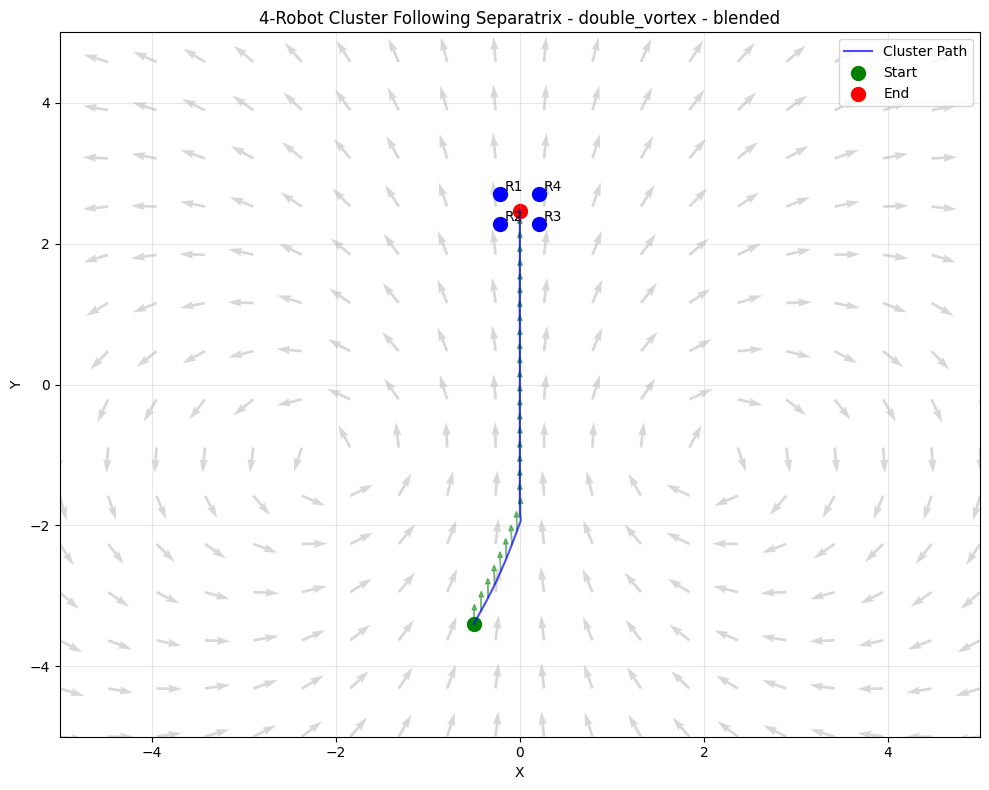

Total distance traveled: 5.98
Final position: [-0.000, 2.469]

Control method: newton_blend
Parameters: {'blend_factor': 0.5}


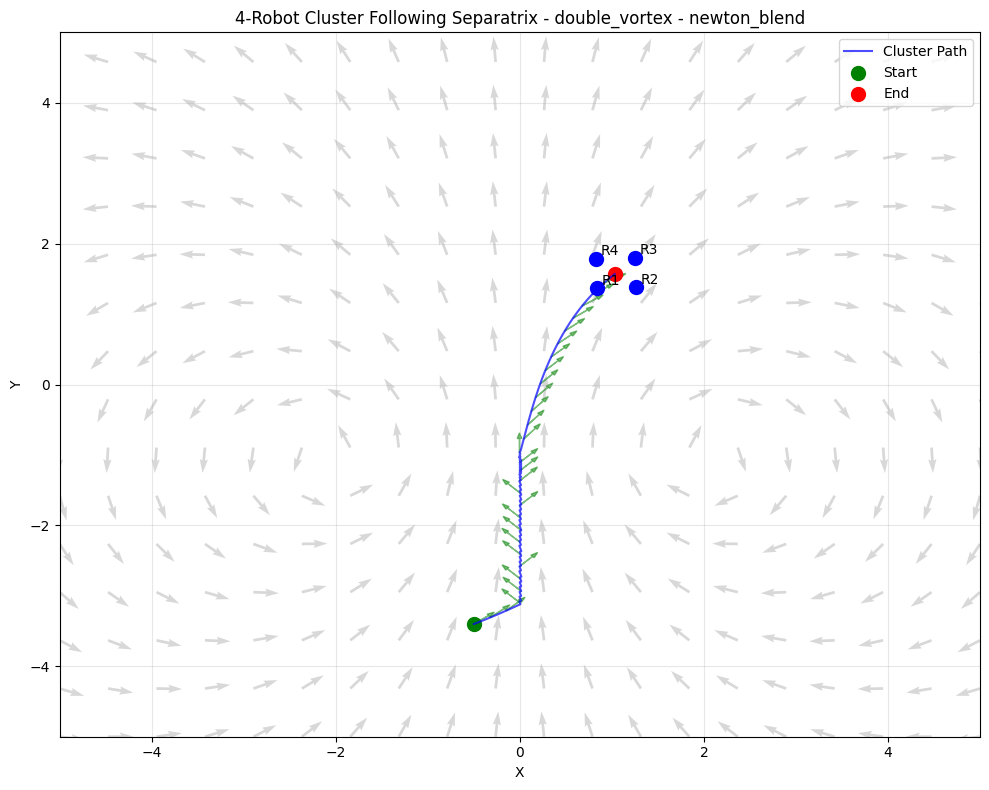

Total distance traveled: 5.98
Final position: [1.032, 1.569]

Control method: newton_like
Parameters: {'newton_weight': 0.1}


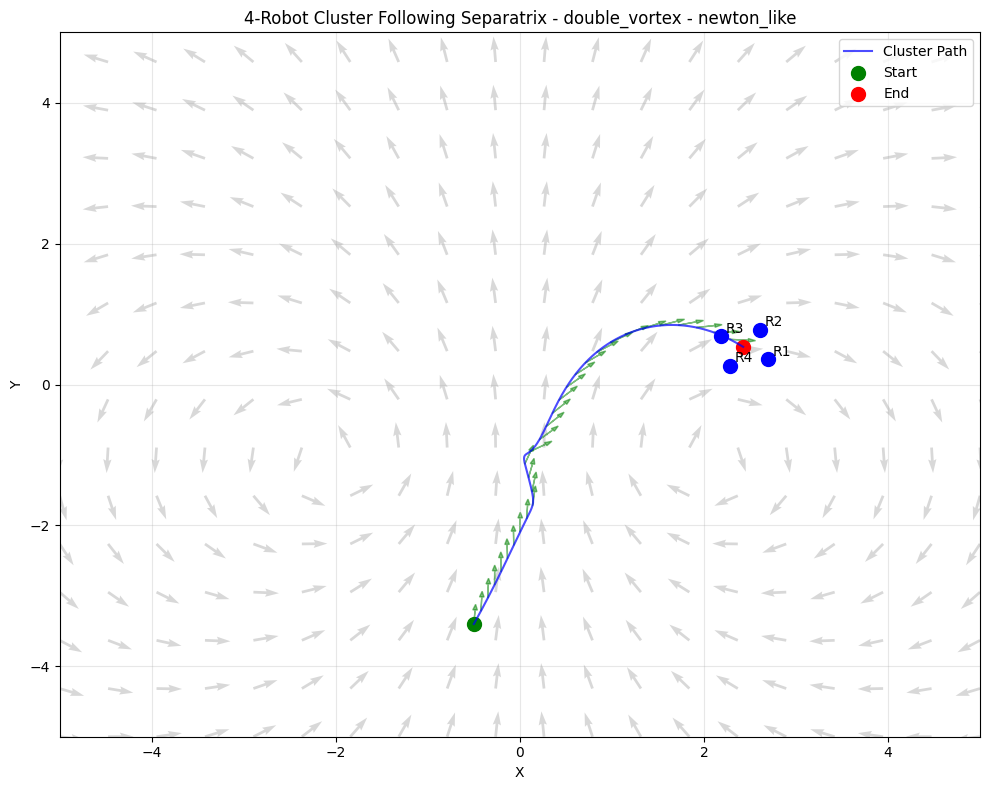

Total distance traveled: 5.98
Final position: [2.427, 0.535]

Testing field type: double_saddle

Control method: blended
Parameters: {'blend_center': 5.0, 'blend_steepness': 2.0}


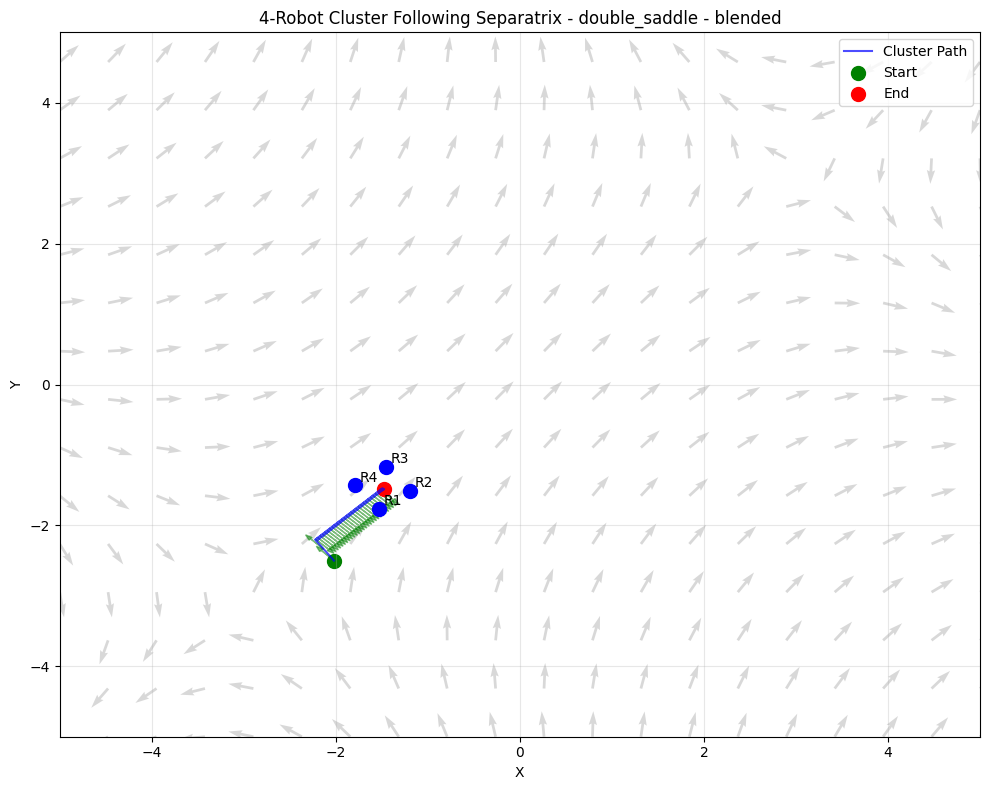

Total distance traveled: 5.98
Final position: [-1.477, -1.485]

Control method: newton_blend
Parameters: {'blend_factor': 0.5}


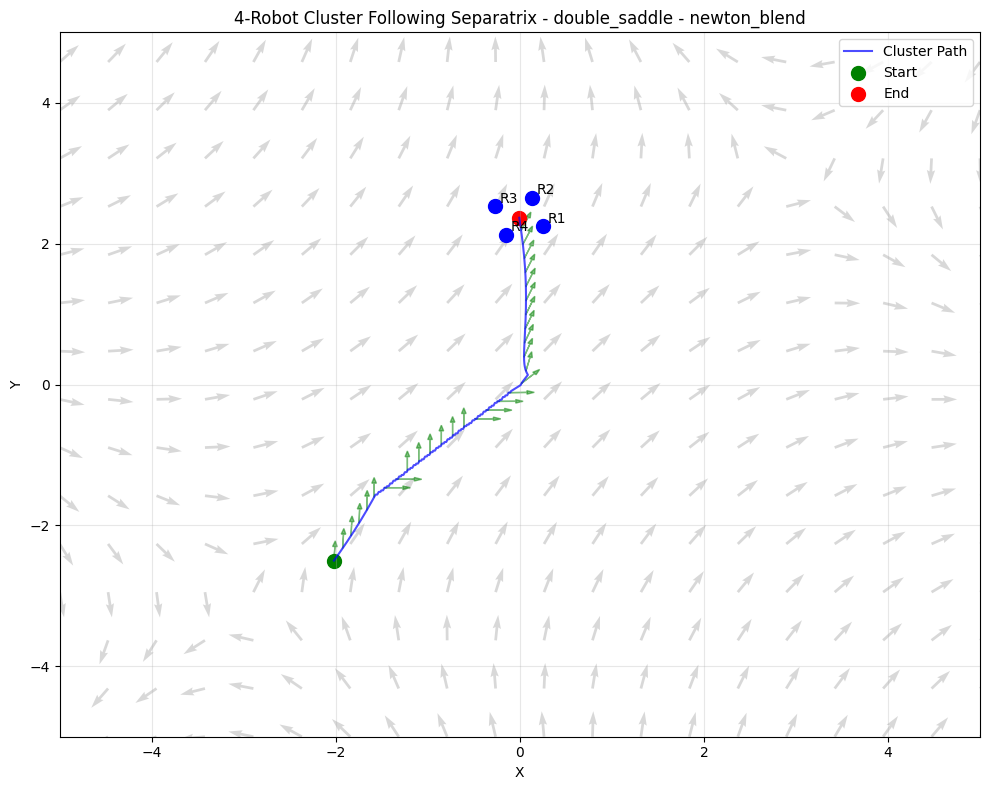

Total distance traveled: 5.98
Final position: [-0.006, 2.368]

Control method: newton_like
Parameters: {'newton_weight': 0.1}


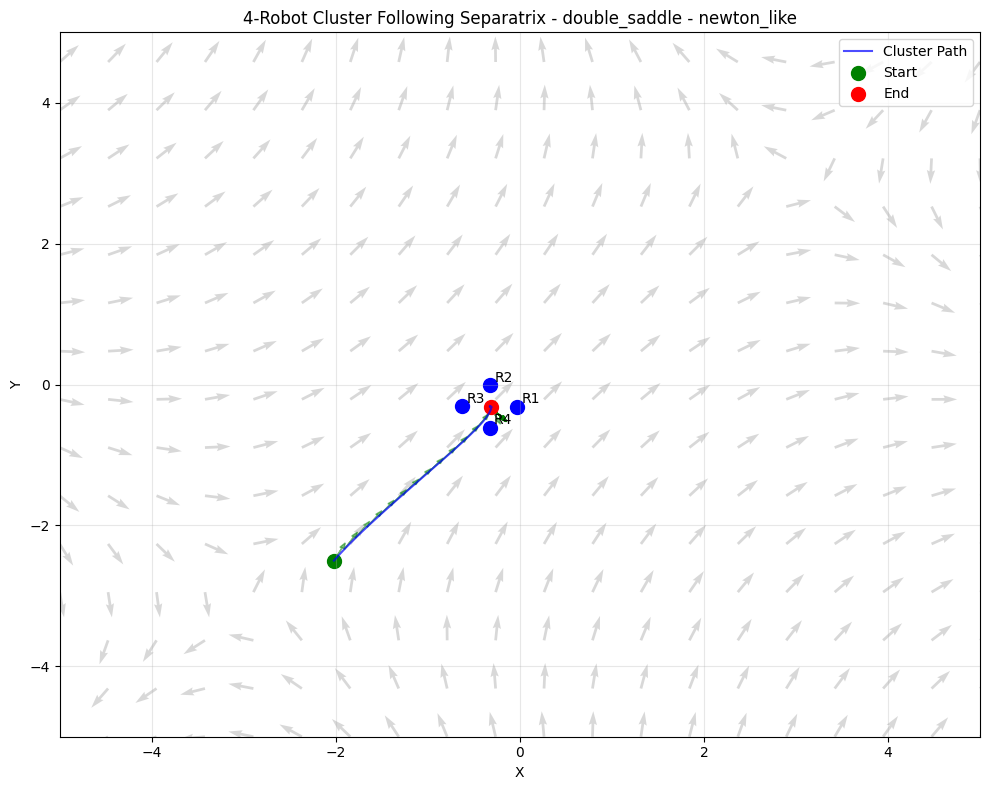

Total distance traveled: 5.98
Final position: [-0.309, -0.318]


In [7]:
# Test configurations
field_types = ['double_vortex', 'double_saddle']
control_methods = [
    ('blended', {'blend_center': 5.0, 'blend_steepness': 2.0}),
    ('newton_blend', {'blend_factor': 0.5}),
    ('newton_like', {'newton_weight': 0.1})
]

# Run simulations
results = {}

for field_type in field_types:
    print(f"\n{'='*60}")
    print(f"Testing field type: {field_type}")
    print(f"{'='*60}")
    
    for method_name, method_params in control_methods:
        print(f"\nControl method: {method_name}")
        print(f"Parameters: {method_params}")
        
        centroid_hist, eigvec_hist, robots = simulate_separatrix_following(
            control_method=method_name,
            field_type=field_type,
            init_mode=2,
            n_steps=300,
            step_size=0.02,
            rotation_rate=0.15,
            correction_weight=0.5,
            manual_offset=0,
            verbose=False,
            **method_params
        )
        
        # Store results
        results[(field_type, method_name)] = (centroid_hist, eigvec_hist, robots)
        
        # Visualize
        title = f"{field_type} - {method_name}"
        fig = visualize_results(centroid_hist, eigvec_hist, robots, 
                               plot_field=True, title_suffix=title)
        plt.show()
        
        # Print summary statistics
        total_distance = np.sum(np.linalg.norm(np.diff(centroid_hist, axis=0), axis=1))
        final_pos = centroid_hist[-1]
        print(f"Total distance traveled: {total_distance:.2f}")
        print(f"Final position: [{final_pos[0]:.3f}, {final_pos[1]:.3f}]")

## Tuning Helper


Trajectory Quality Metrics:
Average speed: 0.0200
Speed std dev: 0.0000
Average direction change: 0.0827 rad
Max direction change: 0.5821 rad
Average |det(J)|: 0.4610
Min |det(J)|: 0.0000


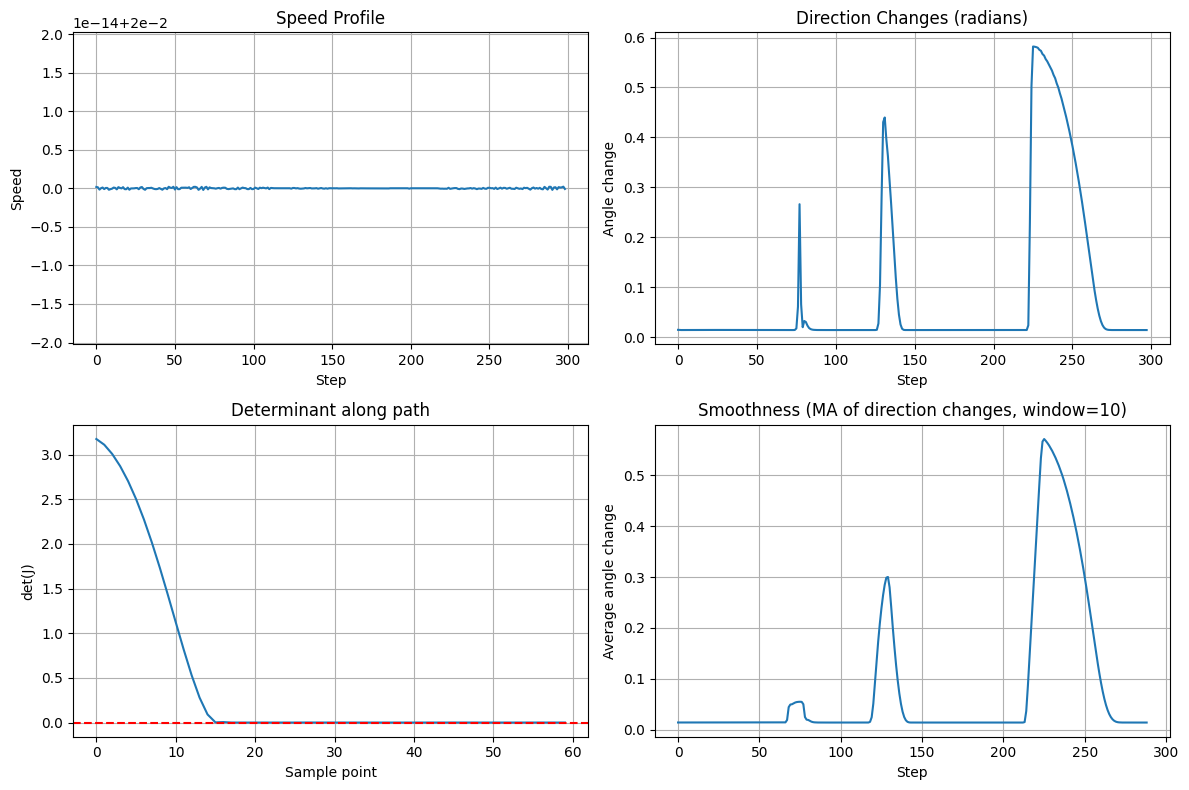

In [8]:
def analyze_trajectory_quality(centroid_history, vector_field, window_size=10):
    """Analyze trajectory quality metrics for tuning."""
    n_points = len(centroid_history)
    
    # Compute metrics
    velocities = np.diff(centroid_history, axis=0)
    speeds = np.linalg.norm(velocities, axis=1)
    
    # Direction changes
    direction_changes = []
    for i in range(1, len(velocities)):
        v1 = velocities[i-1] / (np.linalg.norm(velocities[i-1]) + 1e-6)
        v2 = velocities[i] / (np.linalg.norm(velocities[i]) + 1e-6)
        angle = np.arccos(np.clip(np.dot(v1, v2), -1, 1))
        direction_changes.append(angle)
    
    # Determinant at each point
    determinants = []
    for pos in centroid_history[::5]:  # Sample every 5 points
        J = vector_field.jacobian_twosided(pos[0], pos[1])
        determinants.append(np.linalg.det(J))
    
    # Plot analysis
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))
    
    # Speed profile
    ax1.plot(speeds)
    ax1.set_title('Speed Profile')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Speed')
    ax1.grid(True)
    
    # Direction changes
    ax2.plot(direction_changes)
    ax2.set_title('Direction Changes (radians)')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Angle change')
    ax2.grid(True)
    
    # Determinant along path
    ax3.plot(determinants)
    ax3.axhline(y=0, color='r', linestyle='--')
    ax3.set_title('Determinant along path')
    ax3.set_xlabel('Sample point')
    ax3.set_ylabel('det(J)')
    ax3.grid(True)
    
    # Trajectory smoothness (moving average of direction changes)
    smoothness = np.convolve(direction_changes, np.ones(window_size)/window_size, mode='valid')
    ax4.plot(smoothness)
    ax4.set_title(f'Smoothness (MA of direction changes, window={window_size})')
    ax4.set_xlabel('Step')
    ax4.set_ylabel('Average angle change')
    ax4.grid(True)
    
    plt.tight_layout()
    
    # Print summary
    print(f"\nTrajectory Quality Metrics:")
    print(f"Average speed: {np.mean(speeds):.4f}")
    print(f"Speed std dev: {np.std(speeds):.4f}")
    print(f"Average direction change: {np.mean(direction_changes):.4f} rad")
    print(f"Max direction change: {np.max(direction_changes):.4f} rad")
    print(f"Average |det(J)|: {np.mean(np.abs(determinants)):.4f}")
    print(f"Min |det(J)|: {np.min(np.abs(determinants)):.4f}")
    
    return fig

# Analyze the best performing trajectory
# Example: analyze the blended method on double vortex
if ('double_vortex', 'blended') in results:
    centroid_hist, _, robots = results[('double_vortex', 'blended')]
    analyze_trajectory_quality(centroid_hist, robots.vector_field)